# 07 G-Gene Phylogeny and Haplotype Branch Assignment

**Methods mapping:** G-gene phylogeny and TreeCluster branch assignment.

This notebook documents the IQ-TREE and TreeCluster commands for the input haplotype FASTA files, then parses the resulting branch assignments to rebuild sample-level branch-frequency matrices. Existing tree outputs are reused only when the manifest matches the FASTA checksum, threshold, and commands; set `RSVA_REBUILD_TREE=1` to force regeneration.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('07_g_gene_phylogeny_and_haplotype_branch_assignment', ROOT)
INPUTS = {
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "treecluster_assignments": DATA_DIR / "treecluster_haplotype_assignments.csv",
    "sample_branch_frequency_matrix": DATA_DIR / "sample_branch_frequency_matrix.csv",
    "sample_branch_combinations": DATA_DIR / "sample_treecluster_branch_combinations.csv",
    "treecluster_commands": DATA_DIR / "treecluster_generation_commands.csv",
    "input_manifest": DATA_DIR / "phylogeny_branch_input_manifest.csv",
    "figure_png": FIG_DIR / "Fig3BD_branch_composition_heatmaps.png",
    "figure_pdf": FIG_DIR / "Fig3BD_branch_composition_heatmaps.pdf",
    "figure_svg": FIG_DIR / "Fig3BD_branch_composition_heatmaps.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,metadata,data/metadata/meta_v6_with_season_clade.csv,True
1,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_extracted_4...,True
2,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_extracted_4...,True


### Output paths

,name,relative_path,exists
0,treecluster_assignments,data/processed_data/07_g_gene_phylogeny_and_haplotype...,True
1,sample_branch_frequency_matrix,data/processed_data/07_g_gene_phylogeny_and_haplotype...,True
2,sample_branch_combinations,data/processed_data/07_g_gene_phylogeny_and_haplotype...,True
3,treecluster_commands,data/processed_data/07_g_gene_phylogeny_and_haplotype...,True
4,input_manifest,data/processed_data/07_g_gene_phylogeny_and_haplotype...,True
5,figure_png,results/figures/07_g_gene_phylogeny_and_haplot...,True
6,figure_pdf,results/figures/07_g_gene_phylogeny_and_haplot...,True
7,figure_svg,results/figures/07_g_gene_phylogeny_and_haplot...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/07_g_gene_phylogeny_and_haplotype_branch_assignment'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/07_g_gene_phylogeny_and_haplotype_branch_assignment'))

## Document Input FASTA and Tree Commands

These are the exact commands used to generate the tree and TreeCluster assignments from the input haplotype FASTA files.


In [3]:
commands = au.treecluster_generation_commands(ROOT)
expected_cache = pd.DataFrame([au.expected_treecluster_cache_record(ROOT, project) for project in au.PROJECT_ORDER])

display(commands)
display(expected_cache[['project', 'input_haplotype_fasta', 'input_haplotype_fasta_sha256', 'treecluster_threshold', 'treefile', 'treecluster_output']])


,project,project_label,step,command,output
0,PRJNA1037681,Australia,IQ-TREE,iqtree -s data/input/haplotypes/PRJNA1037681_e...,data/processed_data/treecluster_cache/PRJNA1037681_ex...
1,PRJNA1037681,Australia,TreeCluster,TreeCluster.py -i data/processed_data/treecluster_cac...,data/processed_data/treecluster_cache/PRJNA1037681_ex...
2,PRJNA1130896,United States,IQ-TREE,iqtree -s data/input/haplotypes/PRJNA1130896_e...,data/processed_data/treecluster_cache/PRJNA1130896_ex...
3,PRJNA1130896,United States,TreeCluster,TreeCluster.py -i data/processed_data/treecluster_cac...,data/processed_data/treecluster_cache/PRJNA1130896_ex...


,project,input_haplotype_fasta,input_haplotype_fasta_sha256,treecluster_threshold,treefile,treecluster_output
0,PRJNA1037681,data/input/haplotypes/PRJNA1037681_extracted_4...,28edbbbb6c24514645cd337ec8ccf940d68bd5f33183de...,0.010,data/processed_data/treecluster_cache/PRJNA1037681_ex...,data/processed_data/treecluster_cache/PRJNA1037681_ex...
1,PRJNA1130896,data/input/haplotypes/PRJNA1130896_extracted_4...,ff40875529860da3a8ad6114c0c0a6a16fb97e9ada1ddc...,0.015,data/processed_data/treecluster_cache/PRJNA1130896_ex...,data/processed_data/treecluster_cache/PRJNA1130896_ex...


## Rebuild Branch Assignments

This cell parses TreeCluster assignments and joins them back to haplotype sample IDs parsed from FASTA headers and frequencies.


In [4]:
assignments, branch_matrix, manifest = au.phylogeny_branch_assignment(ROOT, DATA_DIR)

display(manifest)
display(assignments.head())
display(branch_matrix.head())


,project,project_label,input_haplotype_fasta,treefile,treecluster_output,treecluster_threshold,status,commands
0,PRJNA1037681,Australia,data/input/haplotypes/PRJNA1037681_extracted_4...,data/processed_data/treecluster_cache/PRJNA1037681_ex...,data/processed_data/treecluster_cache/PRJNA1037681_ex...,0.010,cache_verified,iqtree -s data/input/haplotypes/PRJNA1037681_e...
1,PRJNA1130896,United States,data/input/haplotypes/PRJNA1130896_extracted_4...,data/processed_data/treecluster_cache/PRJNA1130896_ex...,data/processed_data/treecluster_cache/PRJNA1130896_ex...,0.015,cache_verified,iqtree -s data/input/haplotypes/PRJNA1130896_e...


,SequenceName,ClusterNumber,project,project_label,TreeCluster_branch,SampleID,haplotype_id,haplotype_frequency
0,EPI_ISL_412866,-1,PRJNA1037681,Australia,Unclustered,NaN,NaN,NaN
1,PRJNA1037681_SRR26780041_H3_freq0.090154484241...,1,PRJNA1037681,Australia,C1,SRR26780041,H3,0.090154
2,PRJNA1037681_SRR26779976_H3_freq0.109211827456...,1,PRJNA1037681,Australia,C1,SRR26779976,H3,0.109212
3,PRJNA1037681_SRR26780044_H2_freq0.499396190382...,2,PRJNA1037681,Australia,C2,SRR26780044,H2,0.499396
4,PRJNA1037681_SRR26780044_H1_freq0.500603809617...,2,PRJNA1037681,Australia,C2,SRR26780044,H1,0.500604


,project,SampleID,clade,TreeCluster_combo,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
0,PRJNA1037681,SRR26779971,A.D.3.1,C4+C6,0.000000,0.0,0.0,0.724470,0.0,0.275530,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,PRJNA1037681,SRR26779973,A.D.3.1,C6,0.000000,0.0,0.0,0.000000,0.0,0.198753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PRJNA1037681,SRR26779974,A.D.3.1,C4+C6,0.000000,0.0,0.0,0.714022,0.0,0.285978,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PRJNA1037681,SRR26779976,A.D.3.1,C1+C6,0.109212,0.0,0.0,0.000000,0.0,0.221557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PRJNA1037681,SRR26779980,A.D.3.1,C4+C6,0.000000,0.0,0.0,0.808170,0.0,0.191830,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Figure

Fig. 3B,D uses the regenerated sample-by-branch frequency matrix.


{'png': 'results/figures/07_g_gene_phylogeny_and_haplotype_branch_assignment/Fig3BD_branch_composition_heatmaps.png',
 'pdf': 'results/figures/07_g_gene_phylogeny_and_haplotype_branch_assignment/Fig3BD_branch_composition_heatmaps.pdf',
 'svg': 'results/figures/07_g_gene_phylogeny_and_haplotype_branch_assignment/Fig3BD_branch_composition_heatmaps.svg'}

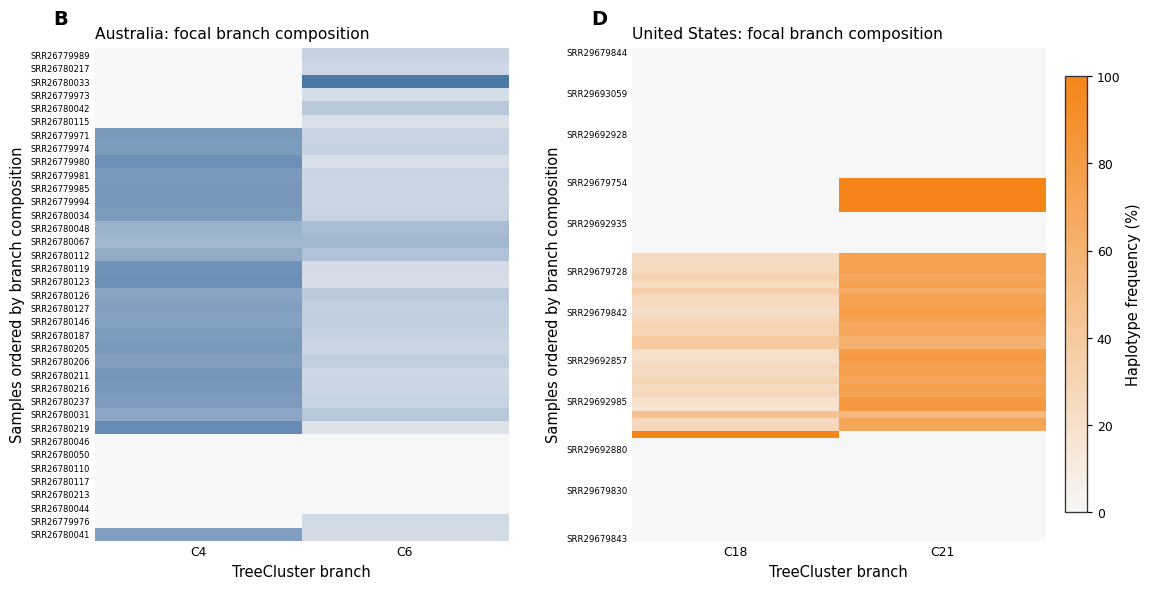

In [5]:
fig, paths = au.draw_branch_frequency_heatmaps(branch_matrix, FIG_DIR)
display(paths)
plt.show()
